In [1]:
!pip install google-colab-selenium pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.9 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [2]:
import time
import re
import pandas as pd
from collections import Counter



class AudienceScraper:
    # запросы по которым ищу на сайте данные
    SEARCH_QUERIES = [
        "поступление за рубежом",
        "учеба за границей",
        "студенческая виза",
        "магистратура за рубежом",
    ]

    def __init__(self):
        import google_colab_selenium as gs
        self.driver = gs.Chrome()
        self.driver.set_page_load_timeout(30)
        self.results = []

    def _scroll_down(self, times = 3, pause = 2): # прогружаю страничку, буквально скролю вниз
        for _ in range(times):
            self.driver.execute_script(
                "window.scrollTo(0, document.body.scrollHeight)")
            time.sleep(pause)

    def _scrape_query(self, query):
        from selenium.webdriver.common.by import By

        url = f"https://pikabu.ru/search?q={query.replace(' ', '%20')}"

        try:
            self.driver.get(url)
            time.sleep(4) # жду загрузку и только потом прогружаю следующую часть сайта
            self._scroll_down(times = 2)
        except Exception as e:
            print(f"ошибка {e}")
            return

        # собираю посты, текст оттуда
        stories = self.driver.find_elements(
            By.CSS_SELECTOR, "article.story, .story-block")
        found = 0
        for story in stories:
            try:
                # заголовок
                title_el = story.find_elements(
                    By.CSS_SELECTOR, ".story__title-link, .story__title a, h2 a")
                title = title_el[0].text.strip() if title_el else ""
                # текст поста
                body_el = story.find_elements(
                    By.CSS_SELECTOR, ".story__content-inner, .story-block__content")
                body = body_el[0].text.strip()[:800] if body_el else ""

                if len(title) > 5 or len(body) > 20:
                    self.results.append({
                        "query": query,
                        "title": title,
                        "text": body,
                        "source": "pikabu.ru",
                    })
                    found += 1
            except Exception:
                continue
        print(f"найдено постов {found}")

    def scrape(self): #собираю dataframe из данных с сайта
        for q in self.SEARCH_QUERIES:
            self._scrape_query(q)
            time.sleep(2)
        self.close()
        df = pd.DataFrame(self.results)
        print(f" собрано постов {len(df)}")
        return df

    def close(self): #закрываю браузер
        try:
            self.driver.quit()
        except Exception:
            pass

    @staticmethod
    def analyze(df): #собираю частоту ключевых слов, тип запросов которые могут быть связаны с поступлением и визой
        if df.empty:
            print("нет данных")
            return {}

        import matplotlib
        matplotlib.rcParams["font.family"] = "DejaVu Sans"
        import matplotlib.pyplot as plt

        # ключевые слова
        pain_keywords = {
            "виза / отказ в визе":   ["виза", "отказ", "консульств", "посольств"],
            "документы / перевод":   ["документ", "перевод", "апостиль", "нострификац"],
            "стоимость / деньги":    ["дорого", "стоимость", "деньги", "цена", "бюджет"],
            "стипендия / грант":     ["стипенди", "грант", "бесплатно", "финансирован"],
            "IELTS / TOEFL / язык":  ["ielts", "toefl", "язык", "английск", "немецк"],
            "мотивационное письмо":  ["мотивационн", "motivation", "letter"],
            "выбор страны / вуза":   ["какой вуз", "какую страну", "куда поступ", "рейтинг"],
            "сроки / дедлайны":      ["срок", "дедлайн", "deadline", "опоздал", "не успе"],
            "сложно / страшно":      ["сложно", "непонятно", "боюсь", "страшно", "помогите"],
            "работа после учёбы":    ["работа", "трудоустрой", "остаться", "после учёбы"],
        }

        all_text = " ".join(
            (df["title"].fillna("") + " " + df["text"].fillna("")).str.lower()
        )

        counts = {}
        for pain, words in pain_keywords.items():
            counts[pain] = sum(all_text.count(w) for w in words)

        top = dict(sorted(counts.items(), key = lambda x: -x[1]))
        top = {k: v for k, v in top.items() if v > 0}

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(list(top.keys())[::-1], list(top.values())[::-1], color = "red")
        ax.set_xlabel("кол-во упоминаний в постах")
        ax.set_title("наиболее интересуемые вещи(темы)", fontweight = "bold")
        plt.tight_layout()
        plt.show()

        print("частота упоминаний тем")
        for k, v in top.items():
            print(f"{k:30} - {v} упоминаний")
        return top

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

найдено постов 16
найдено постов 15
найдено постов 16
найдено постов 16
 собрано постов 63


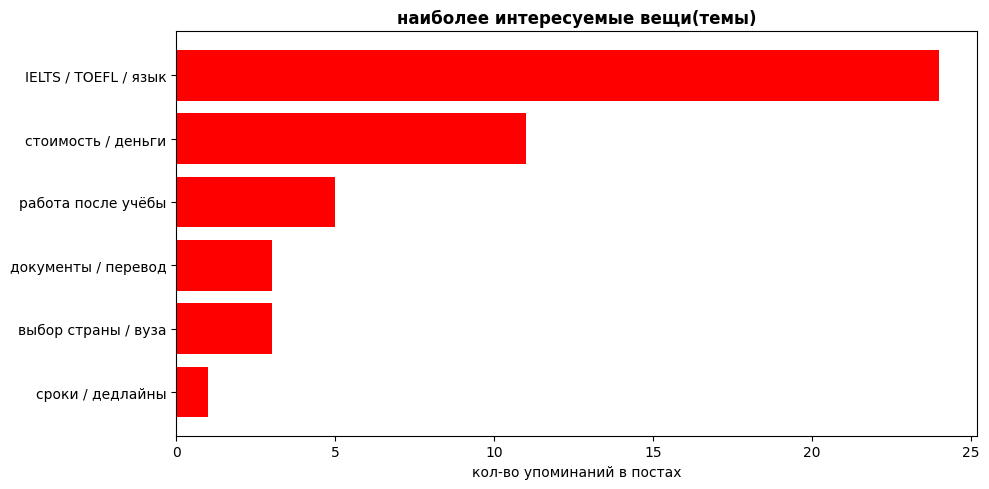

частота упоминаний тем
IELTS / TOEFL / язык           - 24 упоминаний
стоимость / деньги             - 11 упоминаний
работа после учёбы             - 5 упоминаний
документы / перевод            - 3 упоминаний
выбор страны / вуза            - 3 упоминаний
сроки / дедлайны               - 1 упоминаний


{'IELTS / TOEFL / язык': 24,
 'стоимость / деньги': 11,
 'работа после учёбы': 5,
 'документы / перевод': 3,
 'выбор страны / вуза': 3,
 'сроки / дедлайны': 1}

In [3]:
scraper = AudienceScraper()
df = scraper.scrape()
scraper.analyze(df)

In [4]:
df.to_csv("selenium_pikabu.csv", index = False)